In [12]:
# Newton-Raphson Solver
# Author: Owen Purnomo assisted by AI
# Date: 07/01/2026
# We are solving 𝑓(𝑥)=0. The desired level of error (in finding the zero of the function) is 𝜖,
# The initial guess is 𝑥0

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

In [14]:
# Convert a text formula into a function & its derivative

def make_function(expr_str):
    x = sp.symbols('x')
    expr = sp.sympify(expr_str)
    deriv_expr = sp.diff(expr, x)

    f = sp.lambdify(x, expr, modules=['numpy'])
    fprime = sp.lambdify(x, deriv_expr, modules=['numpy'])

    return f, fprime, expr, deriv_expr

In [15]:
# Newton Raphson Algorithm

def newton_raphson(f, fprime, x0, eps, max_iter=100):
    x_k = x0
    records = []
    k = 0

    while k <= max_iter:
        f_xk = f(x_k)
        fprime_xk = fprime(x_k)

        if fprime_xk == 0:
            raise ZeroDivisionError(f"f'(x_k) = 0 at x_k = {x_k}, cannot continue")

        x_k1 = x_k - f_xk / fprime_xk

        records.append({
            "k": k, "x_k": x_k, "f(x_k)": f_xk, "f'(x_k)": fprime_xk,
            "x_k+1": x_k1, "|x_k+1 - x_k|": abs(x_k1 - x_k)
        })

        if abs(x_k1 - x_k) < eps:
            x_star = x_k1
            return x_star, pd.DataFrame(records)

        x_k = x_k1
        k += 1

    raise RuntimeError("Max iterations reached without convergence")

In [16]:
def plot_newton(f, expr, history, x_star, padding=2, n_points=400):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    x_vals_all = list(history["x_k"]) + [x_star]
    x_min, x_max = min(x_vals_all) - padding, max(x_vals_all) + padding
    x_vals = np.linspace(x_min, x_max, n_points)
    y_vals = f(x_vals)

    axes[0].axhline(0, color="black", linewidth=0.8)
    axes[0].plot(x_vals, y_vals, label=f"f(x) = {sp.pretty(expr, use_unicode=False)}", color="steelblue")
    axes[0].scatter(history["x_k"], [f(xk) for xk in history["x_k"]],
                     color="crimson", zorder=5, s=25, label="$x_k$ iterates")
    for _, row in history.iterrows():
        axes[0].annotate(str(int(row["k"])), (row["x_k"], f(row["x_k"])),
                          textcoords="offset points", xytext=(0, 8), fontsize=8, color="crimson")
    axes[0].scatter([x_star], [f(x_star)], color="green", zorder=6, s=60,
                     marker="*", label=f"root ≈ {x_star:.6f}")
    axes[0].set_title("Newton-Raphson iterates on f(x)")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("f(x)")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    axes[1].plot(history["k"], history["|x_k+1 - x_k|"], marker="o", color="darkorange")
    axes[1].set_yscale("log")
    axes[1].set_title("Step size $|x_{k+1} - x_k|$ vs iteration")
    axes[1].set_xlabel("iteration k")
    axes[1].set_ylabel("$|x_{k+1} - x_k|$ (log scale)")
    axes[1].grid(alpha=0.3, which="both")

    plt.tight_layout()
    plt.show()

In [17]:
def solve_newton(expr_str, x0, eps=1e-6, show_table=True, show_plot=True):
    f, fprime, expr, deriv_expr = make_function(expr_str)
    x_star, history = newton_raphson(f, fprime, x0, eps)

    print(f"f(x)  = {expr}")
    print(f"f'(x) = {deriv_expr}")
    print(f"Initial guess: x0 = {x0},  epsilon = {eps}")
    print(f"Approximate root: x* = {x_star:.8f}")
    print(f"f(x*) = {f(x_star):.2e}")
    print(f"Iterations used: {len(history)}")

    if show_table:
        display(history)

    if show_plot:
        plot_newton(f, expr, history, x_star)

    return x_star, history

f(x)  = x**3 - x - 2
f'(x) = 3*x**2 - 1
Initial guess: x0 = 1.5,  epsilon = 1e-06
Approximate root: x* = 1.52137971
f(x*) = 4.53e-14
Iterations used: 3


,k,x_k,f(x_k),f'(x_k),x_k+1,|x_k+1 - x_k|
0,0,1.500000,-1.250000e-01,5.75000,1.521739,2.173913e-02
1,1,1.521739,2.136928e-03,5.94707,1.521380,3.593245e-04
2,2,1.521380,5.893874e-07,5.94379,1.521380,9.916021e-08


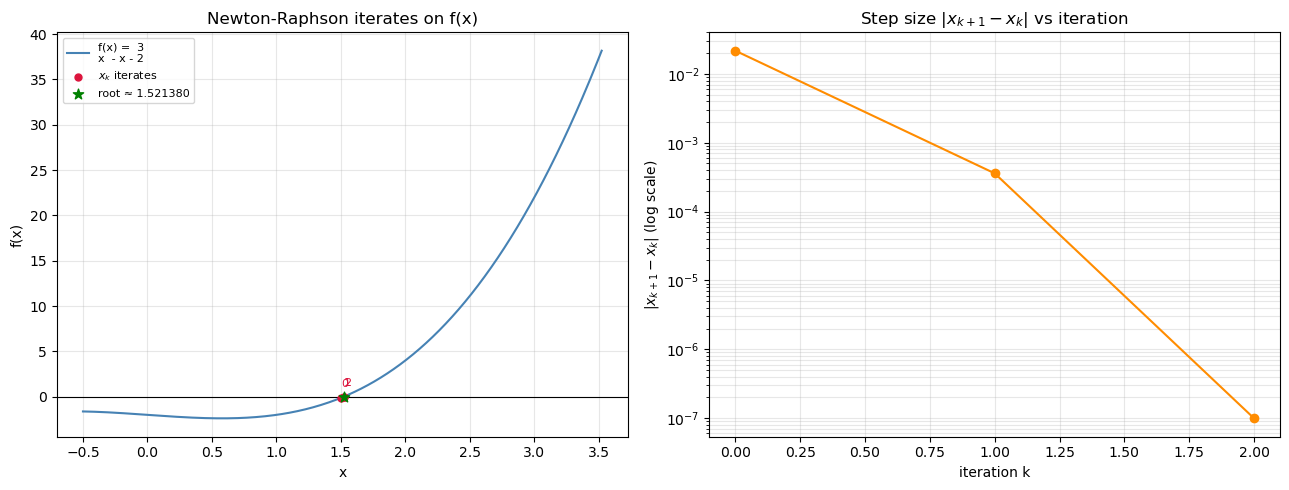

(1.5213797068045751,
    k       x_k        f(x_k)  f'(x_k)     x_k+1  |x_k+1 - x_k|
 0  0  1.500000 -1.250000e-01  5.75000  1.521739   2.173913e-02
 1  1  1.521739  2.136928e-03  5.94707  1.521380   3.593245e-04
 2  2  1.521380  5.893874e-07  5.94379  1.521380   9.916021e-08)

In [18]:
solve_newton("x**3 - x - 2", x0=1.5, eps=1e-6)

f(x)  = -x + cos(x)
f'(x) = -sin(x) - 1
Initial guess: x0 = 1,  epsilon = 1e-08
Approximate root: x* = 0.73908513
f(x*) = 0.00e+00
Iterations used: 4


,k,x_k,f(x_k),f'(x_k),x_k+1,|x_k+1 - x_k|
0,0,1.000000,-4.596977e-01,-1.841471,0.750364,2.496361e-01
1,1,0.750364,-1.892307e-02,-1.681905,0.739113,1.125098e-02
2,2,0.739113,-4.645590e-05,-1.673633,0.739085,2.775753e-05
3,3,0.739085,-2.847206e-10,-1.673612,0.739085,1.701234e-10


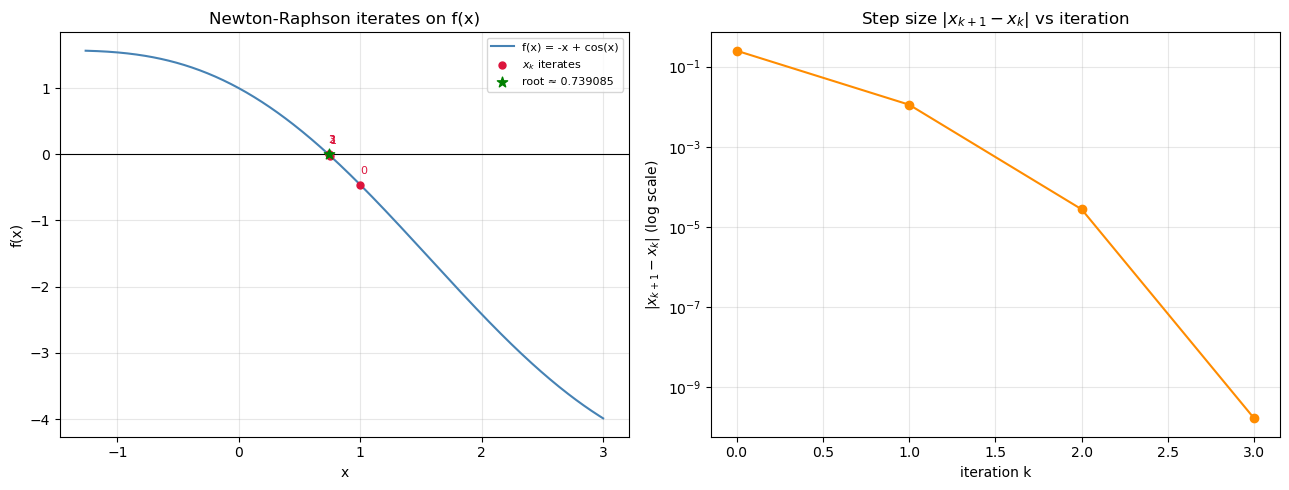

(0.7390851332151607,
    k       x_k        f(x_k)   f'(x_k)     x_k+1  |x_k+1 - x_k|
 0  0  1.000000 -4.596977e-01 -1.841471  0.750364   2.496361e-01
 1  1  0.750364 -1.892307e-02 -1.681905  0.739113   1.125098e-02
 2  2  0.739113 -4.645590e-05 -1.673633  0.739085   2.775753e-05
 3  3  0.739085 -2.847206e-10 -1.673612  0.739085   1.701234e-10)

In [19]:
solve_newton("cos(x) - x", x0=1, eps=1e-8)

f(x)  = -x + exp(-x)
f'(x) = -1 - exp(-x)
Initial guess: x0 = 0,  epsilon = 1e-08
Approximate root: x* = 0.56714329
f(x*) = -1.11e-16
Iterations used: 5


,k,x_k,f(x_k),f'(x_k),x_k+1,|x_k+1 - x_k|
0,0,0.000000,1.000000e+00,-2.000000,0.500000,5.000000e-01
1,1,0.500000,1.065307e-01,-1.606531,0.566311,6.631100e-02
2,2,0.566311,1.304510e-03,-1.567616,0.567143,8.321618e-04
3,3,0.567143,1.964805e-07,-1.567143,0.567143,1.253749e-07
4,4,0.567143,4.440892e-15,-1.567143,0.567143,2.886580e-15


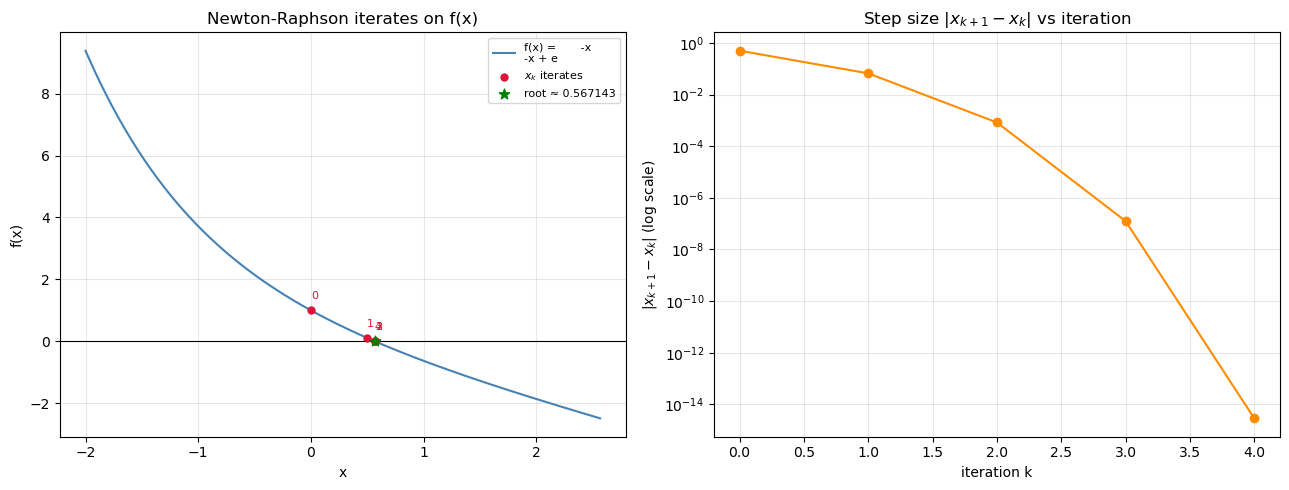

(0.567143290409784,
    k       x_k        f(x_k)   f'(x_k)     x_k+1  |x_k+1 - x_k|
 0  0  0.000000  1.000000e+00 -2.000000  0.500000   5.000000e-01
 1  1  0.500000  1.065307e-01 -1.606531  0.566311   6.631100e-02
 2  2  0.566311  1.304510e-03 -1.567616  0.567143   8.321618e-04
 3  3  0.567143  1.964805e-07 -1.567143  0.567143   1.253749e-07
 4  4  0.567143  4.440892e-15 -1.567143  0.567143   2.886580e-15)

In [20]:
solve_newton("exp(-x) - x", x0=0, eps=1e-8)

f(x)  = x**3 - 3*x + 1
f'(x) = 3*x**2 - 3
Initial guess: x0 = -2,  epsilon = 1e-06
Approximate root: x* = -1.87938524
f(x*) = -8.88e-16
Iterations used: 4


,k,x_k,f(x_k),f'(x_k),x_k+1,|x_k+1 - x_k|
0,0,-2.000000,-1.000000e+00,9.000000,-1.888889,1.111111e-01
1,1,-1.888889,-7.270233e-02,7.703704,-1.879452,9.437322e-03
2,2,-1.879452,-5.038501e-04,7.597015,-1.879385,6.632211e-05
3,3,-1.879385,-2.480070e-08,7.596267,-1.879385,3.264854e-09


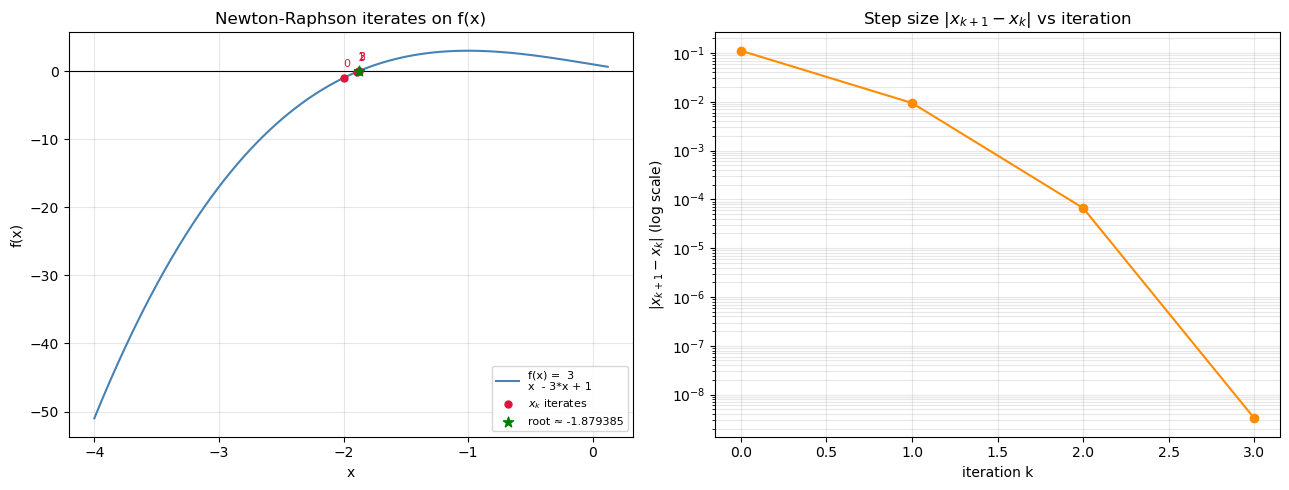

(-1.8793852415718169,
    k       x_k        f(x_k)   f'(x_k)     x_k+1  |x_k+1 - x_k|
 0  0 -2.000000 -1.000000e+00  9.000000 -1.888889   1.111111e-01
 1  1 -1.888889 -7.270233e-02  7.703704 -1.879452   9.437322e-03
 2  2 -1.879452 -5.038501e-04  7.597015 -1.879385   6.632211e-05
 3  3 -1.879385 -2.480070e-08  7.596267 -1.879385   3.264854e-09)

In [21]:
solve_newton("x**3 - 3*x + 1", x0=-2, eps=1e-6)